# Parte 3: Cruce por ubigeo y análisis

## Paso 1

Creen el archivo datos/ubigeos.csv con las columnas ubigeo y departamento.

Para ello, primero se va a importar pandas, para luego elaborar un dataframe con las columnas ubigeo y departamento. Por último, se guarda en un archivo CSV.

In [1]:
import pandas as pd

In [2]:
ubigeos = pd.DataFrame({
    "ubigeo": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"],
    "departamento": ["Amazonas", "Áncash", "Apurímac", "Arequipa", "Ayacucho", "Cajamarca", "Callao", "Cusco", "Huancavelica", "Huánuco", "Ica", "Junín", "La Libertad", "Lambayeque", "Lima", "Loreto", "Madre de Dios", "Moquegua", "Pasco", "Piura", "Puno", "San Martín", "Tacna", "Tumbes", "Ucayali"]
})

# Se guarda el DataFrame en un archivo CSV
ubigeos.to_csv("datos/ubigeos.csv", index=False, encoding="utf-8-sig")
ubigeos

,ubigeo,departamento
0,01,Amazonas
1,02,Áncash
2,03,Apurímac
3,04,Arequipa
4,05,Ayacucho
5,06,Cajamarca
6,07,Callao
7,08,Cusco
8,09,Huancavelica
9,10,Huánuco


## Paso 2

**Enunciado**: Léanlo dos veces: una con pd.read_csv normal y otra con dtype={"ubigeo": str}. Muestren la diferencia y expliquen en una celda de texto por qué importa.

In [3]:
# Lectura 1: read_csv normal. pandas adivina el tipo de cada columna
ubigeos_normal = pd.read_csv("datos/ubigeos.csv")

# Lectura 2: le decimos que la columna ubigeo es texto
ubigeos_texto = pd.read_csv("datos/ubigeos.csv", dtype={"ubigeo": str})

print("Tipo de ubigeo (normal):", ubigeos_normal["ubigeo"].dtype)
print("Tipo de ubigeo (texto): ", ubigeos_texto["ubigeo"].dtype)

# Ponemos las dos lecturas lado a lado para ver la diferencia
comparacion = pd.DataFrame({
    "departamento": ubigeos_texto["departamento"],
    "ubigeo_normal": ubigeos_normal["ubigeo"],
    "ubigeo_texto": ubigeos_texto["ubigeo"],
})
comparacion.head(10)

Tipo de ubigeo (normal): int64
Tipo de ubigeo (texto):  object


,departamento,ubigeo_normal,ubigeo_texto
0,Amazonas,1,01
1,Áncash,2,02
2,Apurímac,3,03
3,Arequipa,4,04
4,Ayacucho,5,05
5,Cajamarca,6,06
6,Callao,7,07
7,Cusco,8,08
8,Huancavelica,9,09
9,Huánuco,10,10


El ubigeo del departamento es un código de 2 dígitos, lo cual está estandarizado por el INEI, por ello se debe respetar la estructura de 2 dígitos. Frente a ello, el parámetro dtype de pd.read_csv permite mantener esa estructura, por lo cual, se recomienda su uso para la lectura del archivo ubigeos.csv. Si no se usara, pandas lo reconocería como número y se perdería el 0 de los primeros 9 códigos de ubigeo. Además, cuando se requiera hacer un cruce de información con otras tablas, el ubigeo suele ser la columna llave para hacer el cruce, si no se respeta la estructura, saldrá error.

## Paso 3

**Enunciado**: Agreguen el `ubigeo` a `decretos_por_departamento.csv` y a `lluvias_por_departamento.csv`.

Para agregarlo se cruza cada tabla con `ubigeos_texto` (la lectura con el ubigeo como texto) usando la columna `departamento`. Se usa `how="left"` para no perder ningún departamento de nuestras tablas: si alguno no encuentra su ubigeo, queda con el ubigeo vacío (`NaN`) y lo revisamos en el paso 4.

In [4]:
# Leemos las dos tablas que guardamos en las partes 1 y 2
decretos = pd.read_csv("datos/decretos_por_departamento.csv")
lluvias = pd.read_csv("datos/lluvias_por_departamento.csv")

# Les agregamos el ubigeo cruzando por el nombre del departamento
decretos = pd.merge(decretos, ubigeos_texto, on="departamento", how="left")
lluvias = pd.merge(lluvias, ubigeos_texto, on="departamento", how="left")

# Ponemos el ubigeo como primera columna para que sea más fácil de leer
decretos = decretos[["ubigeo", "departamento", "declaratorias", "prorrogas"]]
lluvias = lluvias[["ubigeo", "departamento", "capital", "latitud", "longitud",
                   "lluvia_total_mm", "dias_lluvia_fuerte"]]

print("decretos:", decretos.shape)
print("lluvias:", lluvias.shape)

decretos.head()

decretos: (25, 4)
lluvias: (25, 7)


,ubigeo,departamento,declaratorias,prorrogas
0,08,Cusco,8,6
1,02,Áncash,7,6
2,10,Huánuco,7,5
3,01,Amazonas,7,4
4,05,Ayacucho,7,4


In [5]:
lluvias.head()

,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,427.9,0
1,02,Áncash,Huaraz,-9.52614,-77.52869,1415.9,11
2,03,Apurímac,Abancay,-13.63426,-72.88380,820.0,3
3,04,Arequipa,Arequipa,-16.39899,-71.53747,439.4,3
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,500.8,1


## Paso 4

**Enunciado**: **Verificación:** muestren qué departamentos **no encontraron su ubigeo** en cada tabla (por ejemplo, por tildes o nombres escritos distinto). Corríjanlos hasta que no quede ninguno.

Un departamento que no encontró su ubigeo quedó con el `ubigeo` vacío (`NaN`) después del cruce del paso 3. Por eso se buscan las filas con `isna()` en cada tabla.

In [6]:
sin_ubigeo_decretos = decretos[decretos["ubigeo"].isna()]
sin_ubigeo_lluvias = lluvias[lluvias["ubigeo"].isna()]

print("Departamentos sin ubigeo en decretos:", len(sin_ubigeo_decretos))
print(sin_ubigeo_decretos["departamento"].tolist())

print("Departamentos sin ubigeo en lluvias:", len(sin_ubigeo_lluvias))
print(sin_ubigeo_lluvias["departamento"].tolist())

Departamentos sin ubigeo en decretos: 0
[]
Departamentos sin ubigeo en lluvias: 0
[]


En las dos tablas, **ningún departamento se quedó sin ubigeo** (0 y 0), así que no hubo nada que corregir. Esto pasa porque los nombres ya venían escritos igual que en la lista del INEI, con las mismas tildes:

- En `decretos_por_departamento.csv` (Parte 1), los departamentos salen de la lista `departamentos` que da el enunciado, la misma de `ubigeos.csv`.
- En `lluvias_por_departamento.csv` (Parte 2), los nombres vienen de Wikipedia ("Áncash", "Junín", "San Martín", con tilde), y el Callao se agregó escrito como "Callao".

Si algún nombre hubiera venido distinto (por ejemplo "Ancash" sin tilde, o "Provincia Constitucional del Callao"), habría aparecido en la lista de arriba. Lo habríamos corregido con `.replace()` en la columna `departamento` y repetido el cruce del paso 3 hasta que esta celda mostrara 0.

## Paso 5

**Enunciado**: Crucen las dos tablas **por `ubigeo`** (no por nombre).

Se parte de la tabla `lluvias`, que tiene los 25 departamentos, y se le agregan las declaratorias y prórrogas de `decretos` con `how="left"`. De `decretos` solo se toman `ubigeo`, `declaratorias` y `prorrogas`: el nombre del departamento ya está en `lluvias` y así no queda repetido. Con `validate="one_to_one"`, pandas comprueba que cada ubigeo aparezca una sola vez en cada tabla. Si hubiera un ubigeo repetido, el cruce duplicaría filas y pandas avisaría con un error.

In [7]:
tabla_final = pd.merge(
    lluvias,
    decretos[["ubigeo", "declaratorias", "prorrogas"]],
    on="ubigeo",
    how="left",
    validate="one_to_one",
)

# Ordenamos por ubigeo (el Callao, 07, venía al final en la tabla de lluvias)
tabla_final = tabla_final.sort_values("ubigeo").reset_index(drop=True)

print(tabla_final.shape)
tabla_final

(25, 9)


,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,427.9,0,7,4
1,02,Áncash,Huaraz,-9.52614,-77.52869,1415.9,11,7,6
2,03,Apurímac,Abancay,-13.63426,-72.88380,820.0,3,6,2
3,04,Arequipa,Arequipa,-16.39899,-71.53747,439.4,3,7,2
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,500.8,1,7,4
5,06,Cajamarca,Cajamarca,-7.16378,-78.50027,875.7,2,6,2
6,07,Callao,Callao,-12.05162,-77.13452,54.0,0,1,0
7,08,Cusco,Cusco,-13.53188,-71.96701,801.3,4,8,6
8,09,Huancavelica,Huancavelica,-12.78691,-74.97298,930.4,4,7,2
9,10,Huánuco,Huánuco,-9.92882,-76.23989,617.0,4,7,5


## Paso 6

**Enunciado**: **Verificación:** la tabla final debe tener **25 filas**. Los departamentos sin ninguna declaratoria deben aparecer con **0**, no desaparecer.

Como el cruce es `how="left"` desde `lluvias`, ningún departamento desaparece. Si alguno no tuviera fila en `decretos`, quedaría con `NaN` en `declaratorias` y `prorrogas`. Por eso esos vacíos se reemplazan por **0** con `fillna(0)`: que un departamento no tenga decretos significa 0 decretos, no un dato desconocido.

In [8]:
print("Vacíos antes de rellenar:", tabla_final[["declaratorias", "prorrogas"]].isna().sum().sum())

# Los departamentos sin decretos quedan con 0 (y como números enteros, no 7.0)
tabla_final["declaratorias"] = tabla_final["declaratorias"].fillna(0).astype(int)
tabla_final["prorrogas"] = tabla_final["prorrogas"].fillna(0).astype(int)

print("Filas de la tabla final:", len(tabla_final))
print("¿Tiene 25 filas?:", len(tabla_final) == 25)
print("Ubigeos repetidos:", tabla_final["ubigeo"].duplicated().sum())

# Departamentos con 0 declaratorias o 0 prórrogas: deben aparecer, no desaparecer
con_cero = tabla_final[(tabla_final["declaratorias"] == 0) | (tabla_final["prorrogas"] == 0)]
print("Departamentos con 0 declaratorias:", (tabla_final["declaratorias"] == 0).sum())
print("Departamentos con 0 prórrogas:", (tabla_final["prorrogas"] == 0).sum())

con_cero[["ubigeo", "departamento", "declaratorias", "prorrogas"]]

Vacíos antes de rellenar: 0
Filas de la tabla final: 25
¿Tiene 25 filas?: True
Ubigeos repetidos: 0
Departamentos con 0 declaratorias: 0
Departamentos con 0 prórrogas: 2


,ubigeo,departamento,declaratorias,prorrogas
6,07,Callao,1,0
17,18,Moquegua,4,0


La tabla final tiene **25 filas**, sin ubigeos repetidos y sin vacíos. En nuestra temporada (enero a mayo de 2025), **todos los departamentos tuvieron al menos una declaratoria** por lluvias, así que ninguno aparece con 0 declaratorias. Los que sí tienen 0 son **Moquegua y Callao en prórrogas**, y aparecen en la tabla con 0, no desaparecen. Esto funciona por dos razones: el cruce se hizo con `how="left"` desde la tabla de 25 departamentos, y `decretos_por_departamento.csv` ya incluía a los 25 departamentos, también los que tenían 0.

## Paso 7

**Enunciado**: Guarden `datos/tabla_final.csv`. El `ubigeo` debe quedar como texto de 2 dígitos (`01`, no `1`).

Antes de guardar, se asegura que el `ubigeo` sea texto de 2 dígitos con `.astype(str).str.zfill(2)`. `zfill(2)` agrega un cero adelante si el código tiene un solo dígito. En nuestro caso ya venía bien desde el paso 3, pero así queda garantizado. Después se vuelve a leer el archivo guardado para comprobar que el cero de adelante se mantuvo.

In [9]:
# El ubigeo como texto de 2 dígitos ("1" → "01")
tabla_final["ubigeo"] = tabla_final["ubigeo"].astype(str).str.zfill(2)

tabla_final.to_csv("datos/tabla_final.csv", index=False, encoding="utf-8-sig")
print("Guardado datos/tabla_final.csv:", tabla_final.shape)

# Comprobación: volvemos a leer el archivo con el ubigeo como texto
revision = pd.read_csv("datos/tabla_final.csv", dtype={"ubigeo": str})
print("Tipo de ubigeo:", revision["ubigeo"].dtype)
print("¿Todos los ubigeos tienen 2 dígitos?:", (revision["ubigeo"].str.len() == 2).all())
print("Primeros ubigeos:", revision["ubigeo"].head(10).tolist())

revision

Guardado datos/tabla_final.csv: (25, 9)
Tipo de ubigeo: object
¿Todos los ubigeos tienen 2 dígitos?: True
Primeros ubigeos: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']


,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,427.9,0,7,4
1,02,Áncash,Huaraz,-9.52614,-77.52869,1415.9,11,7,6
2,03,Apurímac,Abancay,-13.63426,-72.88380,820.0,3,6,2
3,04,Arequipa,Arequipa,-16.39899,-71.53747,439.4,3,7,2
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,500.8,1,7,4
5,06,Cajamarca,Cajamarca,-7.16378,-78.50027,875.7,2,6,2
6,07,Callao,Callao,-12.05162,-77.13452,54.0,0,1,0
7,08,Cusco,Cusco,-13.53188,-71.96701,801.3,4,8,6
8,09,Huancavelica,Huancavelica,-12.78691,-74.97298,930.4,4,7,2
9,10,Huánuco,Huánuco,-9.92882,-76.23989,617.0,4,7,5


## Paso 8

**Enunciado**: Con **Plotly**, hagan dos gráficos:
- un gráfico de dispersión con `lluvia_total_mm` en el eje X, `declaratorias` en el eje Y y el nombre del departamento en cada punto;
- un gráfico de barras con los 10 departamentos con más declaratorias.

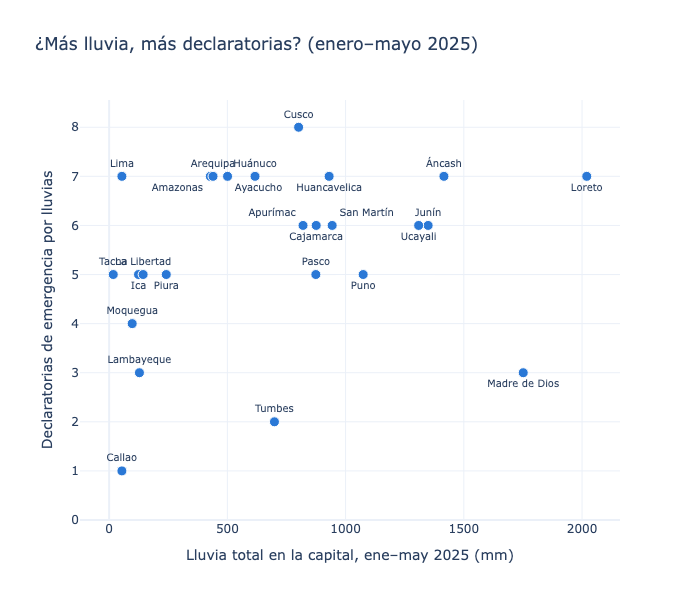

In [10]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "vscode+png"

# Gráfico de dispersión: lluvia (X) vs. declaratorias (Y), con el nombre de cada departamento.
# Varios departamentos tienen el mismo número de declaratorias y lluvias parecidas,
# así que a los que se enciman les ponemos el nombre en otra posición.
# El resto va arriba del punto ("top center").
posicion_especial = {
    "Amazonas": "bottom left", "Ayacucho": "bottom right",
    "Apurímac": "top left", "San Martín": "top right", "Cajamarca": "bottom center",
    "Ica": "bottom center", "Piura": "bottom center",
    "Huancavelica": "bottom center", "Ucayali": "bottom center", "Puno": "bottom center",
    "Madre de Dios": "bottom center", "Loreto": "bottom center",
}
posiciones = tabla_final["departamento"].map(posicion_especial).fillna("top center")

fig_dispersion = px.scatter(
    tabla_final,
    x="lluvia_total_mm",
    y="declaratorias",
    text="departamento",
    hover_data=["capital", "dias_lluvia_fuerte", "prorrogas"],
    labels={
        "lluvia_total_mm": "Lluvia total en la capital, ene–may 2025 (mm)",
        "declaratorias": "Declaratorias de emergencia por lluvias",
        "dias_lluvia_fuerte": "Días con 20 mm o más",
        "capital": "Capital",
        "prorrogas": "Prórrogas",
    },
    title="¿Más lluvia, más declaratorias? (enero–mayo 2025)",
    template="plotly_white",
)
fig_dispersion.update_traces(
    textposition=list(posiciones),
    textfont_size=10,
    marker=dict(size=10, color="#2a78d6", line=dict(width=1, color="white")),
)
fig_dispersion.update_layout(height=600, yaxis=dict(dtick=1, rangemode="tozero"))
fig_dispersion.show()

Departamentos empatados con 6 declaratorias: 5


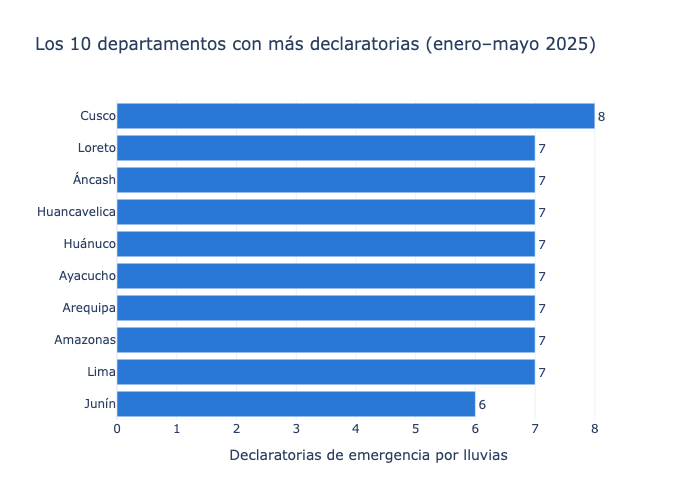

In [11]:
# Gráfico de barras: los 10 departamentos con más declaratorias.
# Ojo: hay empates (8 departamentos tienen 7 declaratorias), así que para
# desempatar ordenamos después por lluvia total, de mayor a menor.
top10 = tabla_final.sort_values(
    ["declaratorias", "lluvia_total_mm"], ascending=[False, False]
).head(10)

print("Departamentos empatados con", top10["declaratorias"].iloc[-1], "declaratorias:",
      (tabla_final["declaratorias"] == top10["declaratorias"].iloc[-1]).sum())

fig_barras = px.bar(
    top10,
    x="declaratorias",
    y="departamento",
    orientation="h",
    text="declaratorias",
    hover_data=["lluvia_total_mm", "prorrogas"],
    labels={
        "declaratorias": "Declaratorias de emergencia por lluvias",
        "departamento": "",
        "lluvia_total_mm": "Lluvia total (mm)",
        "prorrogas": "Prórrogas",
    },
    title="Los 10 departamentos con más declaratorias (enero–mayo 2025)",
    template="plotly_white",
)
fig_barras.update_traces(marker_color="#2a78d6", textposition="outside")
# El primero de la lista arriba
fig_barras.update_layout(height=500, yaxis=dict(autorange="reversed"), xaxis=dict(dtick=1))
fig_barras.show()

## Paso 9

**Enunciado**: Respondan en celdas de texto las 5 preguntas

### 9.1. ¿Cuáles fueron los 3 departamentos con más declaratorias? ¿Coinciden con los 3 donde más llovió?

In [12]:
# Primero ordenamos las columnas (una sola vez)
resumen = tabla_final[["ubigeo", "departamento", "declaratorias", "prorrogas",
                       "lluvia_total_mm", "dias_lluvia_fuerte"]]

# 9.1 Los que tienen más declaratorias y los que tienen más lluvia
print("Más declaratorias:")
display(resumen.sort_values(["declaratorias", "lluvia_total_mm"], ascending=False).head(10))

print("Más lluvia:")
display(resumen.sort_values("lluvia_total_mm", ascending=False).head(10))


Más declaratorias:


,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte
7,08,Cusco,8,6,801.3,4
15,16,Loreto,7,2,2019.9,28
1,02,Áncash,7,6,1415.9,11
8,09,Huancavelica,7,2,930.4,4
9,10,Huánuco,7,5,617.0,4
4,05,Ayacucho,7,4,500.8,1
3,04,Arequipa,7,2,439.4,3
0,01,Amazonas,7,4,427.9,0
14,15,Lima,7,3,54.0,0
11,12,Junín,6,2,1349.1,15


Más lluvia:


,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte
15,16,Loreto,7,2,2019.9,28
16,17,Madre de Dios,3,3,1751.3,30
1,02,Áncash,7,6,1415.9,11
11,12,Junín,6,2,1349.1,15
24,25,Ucayali,6,5,1309.0,21
20,21,Puno,5,3,1074.4,6
21,22,San Martín,6,2,943.3,12
8,09,Huancavelica,7,2,930.4,4
5,06,Cajamarca,6,2,875.7,2
18,19,Pasco,5,2,874.2,1


**Cusco** es el único primero claro, con **8 declaratorias**. Después hay un **empate de 8 departamentos con 7 declaratorias**: Loreto, Áncash, Huancavelica, Huánuco, Ayacucho, Arequipa, Amazonas y Lima. Así que el "top 3" depende de cómo se desempate. Si se desempata por lluvia total, los 3 primeros son **Cusco (8), Loreto (7) y Áncash (7)**.

**Los 3 departamentos donde más llovió** (en su capital) fueron **Loreto (2019.9 mm), Madre de Dios (1751.3 mm) y Áncash (1415.9 mm)**.

**Coinciden solo en parte:** Loreto y Áncash están en las dos listas, pero Cusco no (puesto 12 de 25 en lluvia) y Madre de Dios tampoco: es el segundo con más lluvia y el que tuvo más días de lluvia fuerte (30), pero solo tuvo 3 declaratorias. Además, Lima tiene 7 declaratorias con apenas 54 mm de lluvia en su capital.

### 9.2. ¿Hay departamentos con mucha lluvia y pocas o ninguna declaratoria, o al revés? Den al menos dos razones posibles.

In [13]:
# 9.2 ¿Qué tan relacionadas están la lluvia y las declaratorias? (de -1 a 1)
correlacion = resumen["lluvia_total_mm"].corr(resumen["declaratorias"])
print("Correlación lluvia - declaratorias:", round(correlacion, 2))

# Vemos departamentos con menos declaratorias y menos lluvia. Esto puede ser útil para identificar zonas que podrían necesitar más atención o recursos en caso de lluvias intensas.
print("Menos declaratorias:")
display(resumen.sort_values(["declaratorias", "lluvia_total_mm"], ascending=True).head(10))

print("Menos lluvia:")
display(resumen.sort_values("lluvia_total_mm", ascending=True).head(10))

Correlación lluvia - declaratorias: 0.25
Menos declaratorias:


,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte
6,07,Callao,1,0,54.0,0
23,24,Tumbes,2,2,699.1,7
13,14,Lambayeque,3,1,128.1,0
16,17,Madre de Dios,3,3,1751.3,30
17,18,Moquegua,4,0,97.5,0
22,23,Tacna,5,2,17.4,0
10,11,Ica,5,3,124.3,2
12,13,La Libertad,5,4,143.8,1
19,20,Piura,5,4,241.6,1
18,19,Pasco,5,2,874.2,1


Menos lluvia:


,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte
22,23,Tacna,5,2,17.4,0
14,15,Lima,7,3,54.0,0
6,07,Callao,1,0,54.0,0
17,18,Moquegua,4,0,97.5,0
10,11,Ica,5,3,124.3,2
13,14,Lambayeque,3,1,128.1,0
12,13,La Libertad,5,4,143.8,1
19,20,Piura,5,4,241.6,1
0,01,Amazonas,7,4,427.9,0
3,04,Arequipa,7,2,439.4,3


Sí, en los dos sentidos. La correlación entre lluvia total y declaratorias es de apenas **0.25**: una relación positiva pero débil.

- **Mucha lluvia y pocas declaratorias:**
     **Madre de Dios** con mayores lluvias pero tan solo 3 declaratoria, y **Tumbes** con un total de llvuia de 699.1 mm y solo 2 declaratorias.
- **Poca lluvia y muchas declaratorias:** 
    **Lima** con apenas 54 mm y con 7 declaratorias, **Tacna** con 17.4 mm de lluvia total y 5 declaratorias e **Ica** con 124.3 mm y 5 declaratorias.

**¿Que peude haber pasado?**

- **La lluvia se midió solo en la capital.** Lima, Tacna e Ica tienen capitales en la costa desértica, donde casi no llueve. Pero los decretos declaran emergencia en "varios distritos de algunas provincias" del departamento, que probablemente están en sus **zonas altas andinas**, donde sí llueve fuerte y se producen huaicos que bajan hacia la costa. Un solo punto no representa a todo el departamento.
- **El daño depende de la vulnerabilidad, no solo de la cantidad de lluvia.** En la Amazonía, como en Madre de Dios, llueve mucho todos los años y la población está más acostumbrada a esas lluvias. En zonas áridas y donde la infraestructura no esta adaptada, poca lluvia puede causar mucho daño porque las viviendas, quebradas y canales no están preparados.


### 9.3. ¿Qué porcentaje de las declaratorias fue por peligro inminente y qué porcentaje por impacto de daños? ¿Qué dice eso sobre la gestión del riesgo en su temporada?

In [14]:
import re

# 9.3 Motivo de las declaratorias (sin contar las prórrogas)
decretos_lluvias = pd.read_csv("datos/decretos_lluvias.csv")

declaratorias = decretos_lluvias[decretos_lluvias["tipo"] == "declara"].copy()

# a) Contando cada decreto una vez
print("Decretos de declaratoria:", len(declaratorias))
print((declaratorias["motivo"].value_counts(normalize=True) * 100).round(1), "\n")

# b) Contando departamento por decreto (como en la columna declaratorias de la tabla final):
#    un decreto que menciona 22 departamentos cuenta 22 veces
departamentos = ubigeos_texto["departamento"].tolist()
declaratorias["n_departamentos"] = declaratorias["titulo"].apply(
    lambda titulo: sum(1 for d in departamentos if re.search(r"\b" + d + r"\b", titulo))
)
por_motivo = declaratorias.groupby("motivo")["n_departamentos"].sum()
print("Declaratorias por departamento según motivo:")
print(por_motivo)
print("Total:", por_motivo.sum(), "(debe ser igual a la suma de la columna declaratorias:", tabla_final["declaratorias"].sum(), ")")
print((por_motivo / por_motivo.sum() * 100).round(1))

Decretos de declaratoria: 10
motivo
impacto de daños     90.0
peligro inminente    10.0
Name: proportion, dtype: float64 

Declaratorias por departamento según motivo:
motivo
impacto de daños     115
peligro inminente     22
Name: n_departamentos, dtype: int64
Total: 137 (debe ser igual a la suma de la columna declaratorias: 137 )
motivo
impacto de daños     83.9
peligro inminente    16.1
Name: n_departamentos, dtype: float64


Se cuentan solo las **declaratorias** (sin las prórrogas, que extienden emergencias ya declaradas):

| Forma de contar | Peligro inminente (antes del daño) | Impacto de daños (después) |
|---|---|---|
| Por decreto (10 decretos) | **10 %** (1 decreto) | **90 %** (9 decretos) |
| Por departamento en cada decreto (137 declaratorias) | **16.1 %** (22) | **83.9 %** (115) |

La única declaratoria por peligro inminente fue el **DS 033-2025-PCM** (12 de marzo de 2025), que cubrió 22 departamentos. Por eso pesa más cuando se cuenta por departamento.

**¿Qué dice esto?** En la temporada 2025 la gestión del riesgo fue sobre todo **reactiva**: en 9 de cada 10 decretos, la emergencia se declaró **después** de que las lluvias ya habían causado daños, y no antes para prevenirlos. La declaratoria por peligro inminente permite usar recursos de forma preventiva (limpiar cauces, reforzar defensas ribereñas, reubicar población), así que su poco uso sugiere que se actúa más para atender y reconstruir que para anticiparse. Las 7 prórrogas, todas por impacto de daños, refuerzan esa idea: las emergencias por daños se mantuvieron activas durante meses.

### 9.4. Mencionen al menos tres limitaciones de este análisis.

1. **Un solo punto por departamento.** La lluvia es la de la capital, no la del departamento entero. Por ejemplo, Lima y Callao caen en la misma celda de la grilla de Open-Meteo y tienen exactamente la misma lluvia (54 mm), aunque las emergencias de Lima probablemente se deban a lluvias en sus provincias altas.
2. **Contamos decretos, no distritos ni daños.** Un decreto que cubre un distrito pesa lo mismo que uno que cubre cientos. No medimos personas afectadas, viviendas dañadas ni pérdidas, que serían mejores indicadores de la gravedad.
4. **Una sola temporada y una correlación.** Con 25 departamentos y una temporada (enero a mayo de 2025) no se pueden sacar conclusiones generales, y una correlación no prueba causa y efecto.

### 9.5. Conclusión: ¿El Estado declara emergencia donde más llueve?

De acuerdo a los datos de la temporada de lluvia del 2025, no se puede afirmar que el Estado declare emergencia donde más llueve. Para el periodo hay una relación positiva pero débil entre la lluvia y las declaratorias (correlación de 0.25). Algunos de los departamentos más lluviosos, como Loreto y Áncash, sí están entre los que tienen más declaratorias, pero Madre de Dios, el segundo más lluvioso, tuvo solo 3. Y departamentos casi sin lluvia en su capital, como Lima, Tacna e Ica, tuvieron 5 a 7 declaratorias. Esto nos invita a pensar que las declaratorias pueden responder más al **daño** en zonas vulnerables especificas que a la cantidad total de lluvia. Además, el 90 % de los decretos se dio **después** del impacto, lo que muestra una gestión del riesgo más reactiva que preventiva. Se reconoce que la principal liitacion del estudio es que los datos de lluvia solo miden un punto por departamento.